In [29]:
import pandas as pd 
import numpy as np

In [30]:
import pandas as pd

DATA_PATH = r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\1.customer-churn-prediction-using-ann\Churn_Modelling.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())

print("Shape:", df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Shape: (10000, 14)


In [31]:
print("Info:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
Info: None


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [34]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [35]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [36]:
df.drop(columns = ['RowNumber','CustomerId','Surname'], inplace = True)

In [37]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df = pd.get_dummies(df, columns=['Geography','Gender'] , dtype=int, drop_first = True)

In [39]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [40]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state= 1)

In [42]:
X_train.shape

(8000, 11)

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [44]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [45]:
import tensorflow

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [65]:
model  = Sequential()

model.add(Dense(11, activation = 'relu', input_dim =11))
model.add(Dense(6, activation = 'relu'))
model.add(Dense(1, activation= 'sigmoid'))

In [ ]:
# model = Sequential()

# model.add(Dense(32, activation='relu', input_dim=11))
# model.add(Dense(16, activation='relu'))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))

# # 00/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8653 - loss: 0.3298 - val_accuracy: 0.8450 - val_loss: 0.3586
# # Epoch 12/100
# # 200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8666 - loss: 0.3281 - val_accuracy: 0.8500 - val_loss: 0.3545
# # Epoch 13/100
# # ...
# # Epoch 99/100
# # 200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.2699 - val_accuracy: 0.8462 - val_loss: 0.4060
# # Epoch 100/100
# # 200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8897 - loss: 0.2697 - val_accuracy: 0.8356 - val_loss: 0.4161

d:\Problem_Solving_Practice\Deep_Learning\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam' , metrics=['accuracy'])


In [64]:
history = model.fit(X_train_scaled , y_train , epochs = 100 , validation_split=0.2 )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7969 - loss: 0.4806 - val_accuracy: 0.8081 - val_loss: 0.4441
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4228 - val_accuracy: 0.8219 - val_loss: 0.4187
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8369 - loss: 0.3935 - val_accuracy: 0.8363 - val_loss: 0.3905
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8486 - loss: 0.3643 - val_accuracy: 0.8419 - val_loss: 0.3700
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8564 - loss: 0.3490 - val_accuracy: 0.8438 - val_loss: 0.3670
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8609 - loss: 0.3433 - val_accuracy: 0.8469 - val_loss: 0.3581
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.3383 - val_accuracy: 0.8475 - val_loss: 0.3606
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3352 - val_accu

In [50]:
model.layers[0].get_weights()

[array([[ 0.01924736, -0.74165964,  0.00516037,  0.08597196,  0.16434512,
         -0.29020637,  0.00824817,  0.03077749, -0.13132381,  0.13883412,
         -0.09537508],
        [-0.6473805 , -0.24737604,  0.23354489, -0.23029797, -0.12004157,
         -0.5824676 , -0.10374595,  0.37002936, -0.653117  , -0.09687413,
          0.8223559 ],
        [ 0.17812356, -0.4261241 ,  0.11704585,  0.08136857, -0.2418578 ,
         -0.08272491,  0.1761281 ,  0.15373279,  0.19385378,  0.17207684,
          0.22598816],
        [-0.7168651 , -0.29014406,  0.08587284,  0.31535876, -0.11225276,
         -0.24571662, -0.8380345 ,  0.12410218,  0.16140455, -0.682804  ,
         -0.22429356],
        [ 0.26961398,  0.08848698, -0.8874271 , -0.3853624 ,  0.15538545,
          0.06827301, -0.87529963,  1.0546983 ,  0.07597508, -0.4304964 ,
          0.04577387],
        [-0.01962016, -0.187948  , -0.04920004,  0.09171997,  0.35373688,
         -0.20224188, -0.03506931, -0.01183188, -0.23932572,  0.0296678

In [51]:
model.layers[1].get_weights()

[array([[ 0.5308053 , -0.6614326 , -0.10264554,  0.04526863,  0.17466447,
          0.15016647],
        [ 0.08622038,  0.59063876, -0.08208867, -0.14918186, -0.07393881,
         -0.38763773],
        [-0.47187617,  0.63180393, -0.33029765, -0.39103878,  0.61041874,
         -0.12823872],
        [ 0.50827646, -0.031717  ,  0.14195007,  0.02588602, -0.6177346 ,
         -0.42565835],
        [ 0.71308404,  0.35232198,  0.01023323, -0.05958841, -0.18566011,
         -0.12271477],
        [ 0.24233854, -0.62793106,  0.5261657 , -0.93830365,  0.25989023,
          0.00444716],
        [-0.22807793,  0.27258536, -0.51279163, -0.5056683 ,  0.7103998 ,
         -0.8455155 ],
        [-0.46103838,  0.854186  , -0.4286581 , -0.04961542,  1.159435  ,
         -0.08185131],
        [-0.04142265, -0.6429855 ,  0.18004052,  0.56842804, -0.5596196 ,
          0.16826251],
        [ 0.43627715, -0.00634425,  0.74496865,  0.02004099,  0.04399512,
          0.15223193],
        [-0.59886754,  0.24058

In [52]:
model.layers[2].get_weights()

[array([[-0.9393831],
        [ 1.1530969],
        [-0.6095611],
        [ 1.0472426],
        [ 1.360036 ],
        [-1.5047861]], dtype=float32),
 array([-0.08934614], dtype=float32)]

In [53]:
y_log= model.predict(X_test_scaled)   # output is probablity so we will convert it into 0 and 1 by deciding a threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [54]:
y_pred =  np.where(y_log >0.5, 1, 0)

In [55]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8655

## To increase accuracy 
1. we can increase number of nodes in hidden layer .
2. choose a good activation function like reLU .
3. Increase number of epoch

In [57]:
import matplotlib.pyplot as plt

In [58]:
history.history

{'accuracy': [0.7074999809265137,
  0.8021875023841858,
  0.8114062547683716,
  0.8193749785423279,
  0.8231250047683716,
  0.827343761920929,
  0.8290625214576721,
  0.8340625166893005,
  0.8457812666893005,
  0.8514062762260437,
  0.8553125262260437,
  0.8584374785423279,
  0.8600000143051147,
  0.8589062690734863,
  0.8609374761581421,
  0.864062488079071,
  0.8623437285423279,
  0.8604687452316284,
  0.8609374761581421,
  0.8618749976158142,
  0.8609374761581421,
  0.862500011920929,
  0.8634374737739563,
  0.8626562356948853,
  0.8629687428474426,
  0.8642187714576721,
  0.8643749952316284,
  0.864062488079071,
  0.8634374737739563,
  0.8635937571525574,
  0.86328125,
  0.8645312786102295,
  0.8629687428474426,
  0.864062488079071,
  0.8648437261581421,
  0.8651562333106995,
  0.8656250238418579,
  0.8659374713897705,
  0.8643749952316284,
  0.8626562356948853,
  0.8642187714576721,
  0.864062488079071,
  0.8642187714576721,
  0.8660937547683716,
  0.8635937571525574,
  0.86562502

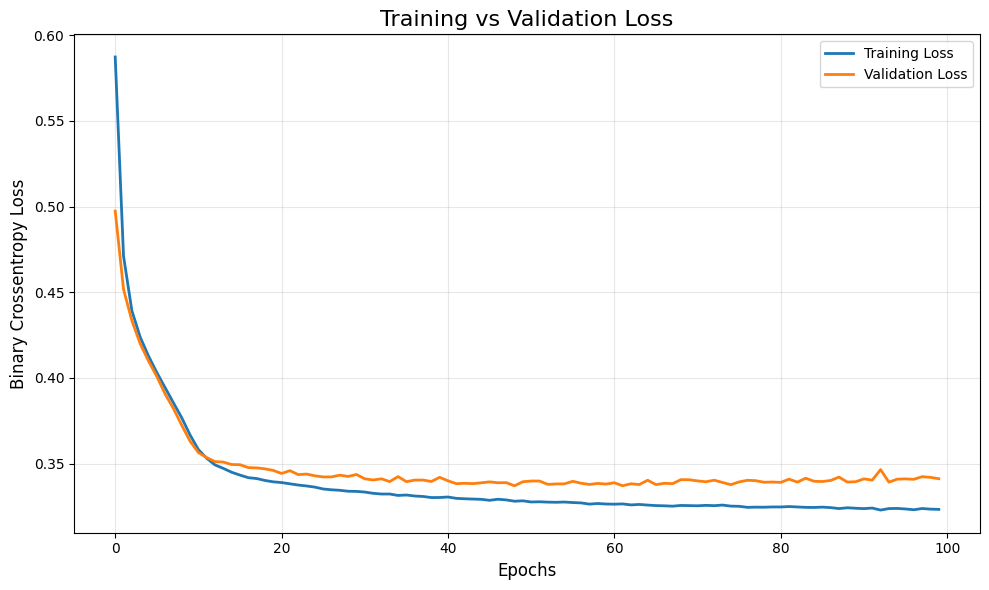

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

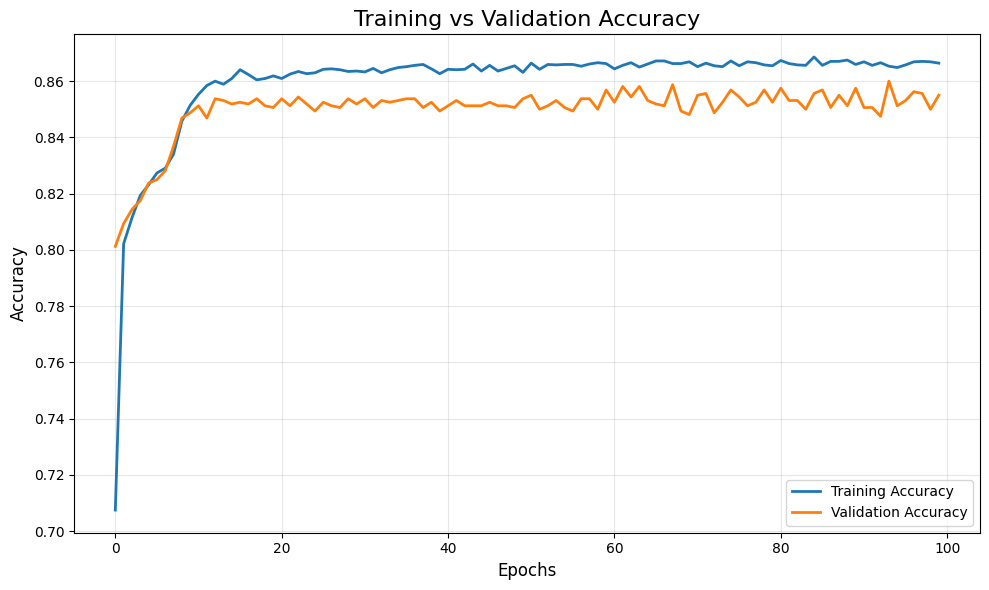

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Training vs Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()